In [31]:
import pandas as pd
df = pd.read_csv("../data/marvel.csv", encoding='latin1')
df.head()



,Title,Distributor(s),Release date(United States),Bud­get (mil­lions),Opening weekend(North America),North America,Other territories,Worldwide
0,Howard the Duck,Universal Pictures,August 1 1986,$37,$5070136,$16295774,$21667000,$37962774
1,Blade,New Line Cinema,August 21 1998,$45,$17073856,$70087718,$61095812,$131183530
2,X-Men,20th Century Fox,July 14 2000,$75,$54471475,$157299717,$139039810,$296339527
3,Blade II,New Line Cinema,March 22 2002,$54,$32528016,$82348319,$72661713,$155010032
4,Spider-Man,Sony Pictures,May 3 2002,$139,$114844116,$403706375,$418002176,$821708551


In [32]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Title                           66 non-null     str  
 1   Distributor(s)                  66 non-null     str  
 2   Release date(United States)     66 non-null     str  
 3   Bud­get (mil­lions)             65 non-null     str  
 4   Opening weekend(North America)  66 non-null     str  
 5   North America                   66 non-null     str  
 6   Other territories               66 non-null     str  
 7   Worldwide                       66 non-null     str  
dtypes: str(8)
memory usage: 4.3 KB


Title                             0
Distributor(s)                    0
Release date(United States)       0
Bud­get (mil­lions)               1
Opening weekend(North America)    0
North America                     0
Other territories                 0
Worldwide                         0
dtype: int64

In [33]:
money_cols = ['Bud­get (mil­lions)', 'Opening weekend(North America)', 
              'North America', 'Other territories', 'Worldwide']

for col in money_cols:
    df[col] = pd.to_numeric(df[col].replace(r'[\$,]', '', regex=True), errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Title                           66 non-null     str    
 1   Distributor(s)                  66 non-null     str    
 2   Release date(United States)     66 non-null     str    
 3   Bud­get (mil­lions)             65 non-null     float64
 4   Opening weekend(North America)  66 non-null     int64  
 5   North America                   66 non-null     int64  
 6   Other territories               66 non-null     int64  
 7   Worldwide                       66 non-null     int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 4.3 KB


In [34]:
df.isnull().sum()

Title                             0
Distributor(s)                    0
Release date(United States)       0
Bud­get (mil­lions)               1
Opening weekend(North America)    0
North America                     0
Other territories                 0
Worldwide                         0
dtype: int64

In [35]:
df['Bud­get (mil­lions)'] = df['Bud­get (mil­lions)'].fillna(
    df['Bud­get (mil­lions)'].mean()
)
df.isnull().sum()

Title                             0
Distributor(s)                    0
Release date(United States)       0
Bud­get (mil­lions)               0
Opening weekend(North America)    0
North America                     0
Other territories                 0
Worldwide                         0
dtype: int64

In [36]:
df['Release date(United States)'] = pd.to_datetime(
    df['Release date(United States)'], errors='coerce'
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Title                           66 non-null     str           
 1   Distributor(s)                  66 non-null     str           
 2   Release date(United States)     64 non-null     datetime64[us]
 3   Bud­get (mil­lions)             66 non-null     float64       
 4   Opening weekend(North America)  66 non-null     int64         
 5   North America                   66 non-null     int64         
 6   Other territories               66 non-null     int64         
 7   Worldwide                       66 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(4), str(2)
memory usage: 4.3 KB


In [37]:
df = df.dropna(subset=['Release date(United States)'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Title                           64 non-null     str           
 1   Distributor(s)                  64 non-null     str           
 2   Release date(United States)     64 non-null     datetime64[us]
 3   Bud­get (mil­lions)             64 non-null     float64       
 4   Opening weekend(North America)  64 non-null     int64         
 5   North America                   64 non-null     int64         
 6   Other territories               64 non-null     int64         
 7   Worldwide                       64 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(4), str(2)
memory usage: 4.1 KB


In [38]:
df['Profit'] = df['Worldwide'] - df['Bud­get (mil­lions)']
df['Year'] = df['Release date(United States)'].dt.year

In [39]:
def category(x):
    if x < 300_000_000:
        return "Low"
    elif x <= 800_000_000:
        return "Medium"
    else:
        return "High"

df['Revenue_Category'] = df['Worldwide'].apply(category)

In [40]:
df[['Worldwide', 'Revenue_Category', 'Profit', 'Year']].head()
df['Revenue_Category'].value_counts()
df.head()

,Title,Distributor(s),Release date(United States),Bud­get (mil­lions),Opening weekend(North America),North America,Other territories,Worldwide,Profit,Year,Revenue_Category
0,Howard the Duck,Universal Pictures,1986-08-01,37.0,5070136,16295774,21667000,37962774,37962737.0,1986,Low
1,Blade,New Line Cinema,1998-08-21,45.0,17073856,70087718,61095812,131183530,131183485.0,1998,Low
2,X-Men,20th Century Fox,2000-07-14,75.0,54471475,157299717,139039810,296339527,296339452.0,2000,Low
3,Blade II,New Line Cinema,2002-03-22,54.0,32528016,82348319,72661713,155010032,155009978.0,2002,Low
4,Spider-Man,Sony Pictures,2002-05-03,139.0,114844116,403706375,418002176,821708551,821708412.0,2002,High


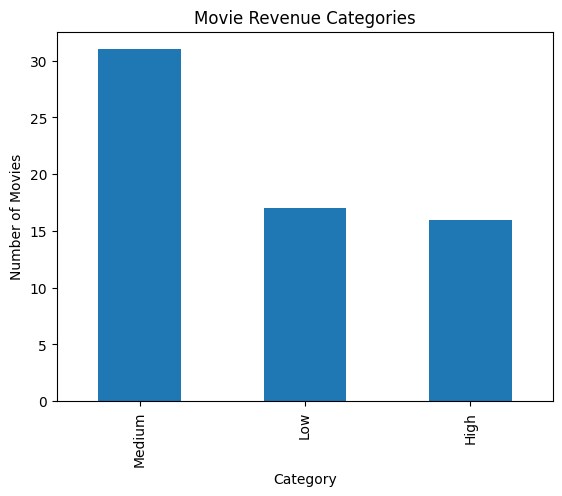

In [41]:
import matplotlib.pyplot as plt

df['Revenue_Category'].value_counts().plot(kind='bar')

plt.title("Movie Revenue Categories")
plt.xlabel("Category")
plt.ylabel("Number of Movies")

plt.show()

In [42]:
df.sort_values(by='Worldwide', ascending=False).head(5)

,Title,Distributor(s),Release date(United States),Bud­get (mil­lions),Opening weekend(North America),North America,Other territories,Worldwide,Profit,Year,Revenue_Category
55,Avengers: Endgame,Walt Disney Studios Motion Pictures,2019-04-26,356.0,357115007,858373000,1937901401,2797800564,2.797800e+09,2019,High
49,Avengers: Infinity War,Walt Disney Studios Motion Pictures,2018-04-27,316.0,257698183,678815482,1369544272,2048359754,2.048359e+09,2018,High
63,Spider-Man: No Way Home,Sony Pictures,2021-12-17,200.0,260138569,780418859,1072000000,1852418859,1.852419e+09,2021,High
26,The Avengers,Walt Disney Studios Motion Pictures,2012-05-04,220.0,207438708,623357910,895455078,1518812988,1.518813e+09,2012,High
36,Avengers: Age of Ultron,Walt Disney Studios Motion Pictures,2015-05-01,250.0,191271109,459005868,946397826,1405403694,1.405403e+09,2015,High


In [43]:
df.sort_values(by='Worldwide').head(5)

,Title,Distributor(s),Release date(United States),Bud­get (mil­lions),Opening weekend(North America),North America,Other territories,Worldwide,Profit,Year,Revenue_Category
46,Inhumans,IMAX Entertainment,2017-09-01,277.666954,1500000,1521787,1330495,2852282,2.852004e+06,2017,Low
19,Punisher: War Zone,Lionsgate Films,2008-12-05,35.000000,4271451,8050977,2049059,10100036,1.010000e+07,2008,Low
0,Howard the Duck,Universal Pictures,1986-08-01,37.000000,5070136,16295774,21667000,37962774,3.796274e+07,1986,Low
58,The New Mutants,20th Century Studios,2020-08-28,67.000000,7037017,23855569,24819497,48675066,4.867500e+07,2020,Low
8,The Punisher,Lionsgate Films,2004-04-16,33.000000,13834527,33810189,20889916,54700105,5.470007e+07,2004,Low


In [44]:
df.to_csv("../data/cleaned_marvel.csv", index=False)